# Redraw Output Figures

This notebook rebuilds the presentation-ready figures with a cleaner, more consistent style.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import f1_score, roc_auc_score

THEME = {
    "catboost": "#8C2D19",
    "lightgbm": "#2F5D73",
    "validation": "#8C2D19",
    "test": "#2F5D73",
    "mlp": "#7B6D8D",
    "logreg": "#B8860B",
    "accent": "#B30D0D",
    "soft_fill": "#D8CBC6",
    "muted_fill": "#C9B7B0",
    "grid": "#E8DFDB",
    "edge": "#D9CDC7",
    "text": "#1F1A17",
    "muted": "#6E625B",
    "bg": "#FFFFFF",
}

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["bg"],
    "savefig.facecolor": THEME["bg"],
    "axes.edgecolor": THEME["edge"],
    "axes.labelcolor": THEME["text"],
    "text.color": THEME["text"],
    "xtick.color": THEME["muted"],
    "ytick.color": THEME["muted"],
    "grid.color": THEME["grid"],
    "grid.linewidth": 0.9,
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 15,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 12.5,
    "font.family": "DejaVu Sans",
})


def finish_axis(ax):
    ax.grid(axis="y", alpha=0.85)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def model_style(name: str) -> dict:
    if "CatBoost" in name:
        return {"color": THEME["catboost"], "marker": "o", "linestyle": "-", "linewidth": 3.1, "alpha": 0.98, "zorder": 4}
    if "LightGBM" in name:
        return {"color": THEME["lightgbm"], "marker": "s", "linestyle": "--", "linewidth": 3.0, "alpha": 0.98, "zorder": 4}
    if "MLP" in name:
        return {"color": THEME["mlp"], "marker": "^", "linestyle": "-.", "linewidth": 2.3, "alpha": 0.82, "zorder": 3}
    return {"color": THEME["logreg"], "marker": "D", "linestyle": ":", "linewidth": 2.3, "alpha": 0.82, "zorder": 3}


def split_style(split_name: str) -> dict:
    if split_name == "validation":
        return {"color": THEME["validation"], "marker": "o", "linestyle": "--"}
    return {"color": THEME["test"], "marker": "s", "linestyle": "-"}


In [16]:
PROJECT_ROOT = Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs" if (PROJECT_ROOT / "outputs").exists() else PROJECT_ROOT

print({
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "OUTPUT_DIR": str(OUTPUT_DIR),
})


{'PROJECT_ROOT': '/Users/bettinabopeng/Documents/GitHub/5971', 'OUTPUT_DIR': '/Users/bettinabopeng/Documents/GitHub/5971/outputs'}


In [17]:
main_summary = pd.read_csv(OUTPUT_DIR / "main_model_summary.csv")
main_predictions = pd.read_parquet(OUTPUT_DIR / "main_predictions.parquet")
ablation_summary = pd.read_csv(OUTPUT_DIR / "ablation_summary.csv")

display(main_summary.head())
display(main_predictions.head())
display(ablation_summary.head())


,model,stage,split,auc,pr_auc,logloss,precision@11,recall@11,f1@11,hit@11,avg_k@11,precision@dynamic_k,recall@dynamic_k,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,modal_best_params
0,LightGBM,plus_als,test,0.831461,0.417650,0.248845,0.298596,0.573810,0.345304,0.877796,11.0,0.330528,0.516641,0.372787,0.840844,9.871686,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."
1,CatBoost,plus_als,test,0.832148,0.416664,0.543755,0.299120,0.575332,0.345977,0.878702,11.0,0.330396,0.516523,0.372579,0.840456,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
2,MLP,plus_als,test,0.810751,0.394816,0.260764,0.290682,0.564002,0.337451,0.874467,11.0,0.321445,0.504463,0.363119,0.836221,9.871686,"{'model__learning_rate_init': 0.001, 'model__h..."
3,LogisticRegression_SAGA,plus_als,test,0.812705,0.352413,0.670847,0.286846,0.559394,0.333664,0.875081,11.0,0.316678,0.497000,0.357777,0.834120,9.871686,"{'model__max_iter': 300, 'model__C': 3.0}"
4,LightGBM,plus_als,validation,0.831310,0.418410,0.250606,0.299668,0.574611,0.346492,0.878116,11.0,0.330593,0.518430,0.372905,0.841583,9.965795,"{'subsample': 1.0, 'reg_lambda': 3.0, 'num_lea..."


,user_id,product_id,label,u_avg_basket_size,user_cluster,prob,model,stage,split
0,12,5746,0,13.0,2,0.731356,LogisticRegression_SAGA,plus_als,validation
1,12,5876,0,13.0,2,0.582754,LogisticRegression_SAGA,plus_als,validation
2,12,7076,1,13.0,2,0.788669,LogisticRegression_SAGA,plus_als,validation
3,12,8239,0,13.0,2,0.724135,LogisticRegression_SAGA,plus_als,validation
4,12,10863,1,13.0,2,0.769433,LogisticRegression_SAGA,plus_als,validation


,model,stage,split,n_features,auc,pr_auc,logloss,precision@11,recall@11,f1@11,hit@11,avg_k@11,precision@dynamic_k,recall@dynamic_k,f1@dynamic_k,hit@dynamic_k,avg_k@dynamic_k,fixed_params
0,CatBoost,interaction_only,test,8,0.826913,0.408693,0.505496,0.295922,0.567948,0.342074,0.874693,11.0,0.327454,0.510078,0.368930,0.837515,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
1,CatBoost,plus_user_product,test,18,0.833186,0.417726,0.497530,0.299164,0.575791,0.346097,0.879187,11.0,0.331008,0.517516,0.373251,0.841976,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
2,CatBoost,plus_kmeans,test,22,0.833723,0.418207,0.497537,0.299405,0.576002,0.346346,0.879187,11.0,0.331048,0.518028,0.373388,0.841911,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
3,CatBoost,plus_apriori,test,23,0.833739,0.418249,0.497495,0.299516,0.576062,0.346431,0.879057,11.0,0.331248,0.518112,0.373553,0.841879,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."
4,CatBoost,plus_als,test,25,0.832173,0.416683,0.543150,0.299175,0.575264,0.346030,0.878637,11.0,0.330513,0.516861,0.372749,0.840489,9.871686,"{'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'i..."


In [18]:
def make_k_map(df_input: pd.DataFrame, strategy: str = "rounded_avg_basket", fixed_k: int = 11) -> dict[int, int]:
    user_k = df_input.groupby("user_id")["u_avg_basket_size"].first().reset_index()
    if strategy == "fixed_11":
        user_k["pred_k"] = fixed_k
    elif strategy == "rounded_avg_basket":
        user_k["pred_k"] = np.rint(user_k["u_avg_basket_size"]).astype(int).clip(lower=1)
    elif strategy == "ceil_avg_basket":
        user_k["pred_k"] = np.ceil(user_k["u_avg_basket_size"]).astype(int).clip(lower=1)
    else:
        raise ValueError(strategy)
    return dict(zip(user_k["user_id"], user_k["pred_k"]))


def compute_segment_summary(pred_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_name, model_df in pred_df.groupby("model"):
        for split_name, split_df in model_df.groupby("split"):
            dynamic_map = make_k_map(split_df, "rounded_avg_basket")
            ranked = split_df.sort_values(["user_id", "prob", "product_id"], ascending=[True, False, True]).copy()
            ranked["rank_within_user"] = ranked.groupby("user_id").cumcount() + 1
            ranked["pred_k_dynamic"] = ranked["user_id"].map(dynamic_map).astype(int)
            ranked["pred_top_dynamic"] = (ranked["rank_within_user"] <= ranked["pred_k_dynamic"]).astype(int)

            for segment_value, g in ranked.groupby("user_cluster"):
                per_user_f1_dyn = []
                for _, gu in g.groupby("user_id"):
                    y_true = gu["label"].to_numpy()
                    pred_dyn = gu["pred_top_dynamic"].to_numpy()
                    per_user_f1_dyn.append(f1_score(y_true, pred_dyn, zero_division=0))

                rows.append({
                    "model": model_name,
                    "split": split_name,
                    "segment": int(segment_value),
                    "users": int(g["user_id"].nunique()),
                    "auc": float(roc_auc_score(g["label"].to_numpy(), g["prob"].to_numpy())),
                    "f1@dynamic_k": float(np.mean(per_user_f1_dyn)),
                })
    return pd.DataFrame(rows).sort_values(["split", "model", "segment"]).reset_index(drop=True)


segment_summary_path = OUTPUT_DIR / "segment_summary_rebuilt.csv"
if segment_summary_path.exists():
    segment_summary = pd.read_csv(segment_summary_path)
else:
    segment_summary = compute_segment_summary(main_predictions)
    segment_summary.to_csv(segment_summary_path, index=False)

display(segment_summary)


,model,split,segment,users,auc,f1@dynamic_k
0,CatBoost,test,0,5518,0.813907,0.424049
1,CatBoost,test,1,6200,0.771977,0.331581
2,CatBoost,test,2,9315,0.794678,0.353986
3,CatBoost,test,3,9899,0.854245,0.387061
4,LightGBM,test,0,5518,0.812827,0.424745
5,LightGBM,test,1,6200,0.771183,0.332269
6,LightGBM,test,2,9315,0.793696,0.354011
7,LightGBM,test,3,9899,0.853663,0.386869
8,LogisticRegression_SAGA,test,0,5518,0.803651,0.414709
9,LogisticRegression_SAGA,test,1,6200,0.763099,0.326383


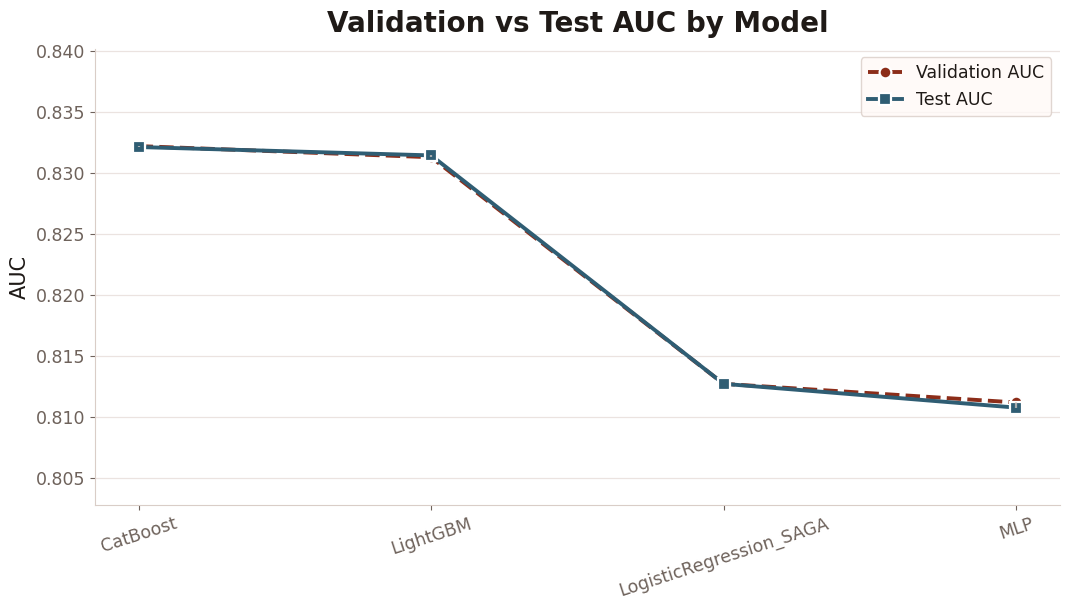

In [19]:
plot_df = (
    main_summary.pivot(index="model", columns="split", values="auc")
    .reset_index()
    .dropna(subset=["validation", "test"], how="any")
)

model_order = plot_df["model"].tolist()
x = np.arange(len(model_order))
ymin = max(0.0, plot_df[["validation", "test"]].min().min() - 0.008)
ymax = min(1.0, plot_df[["validation", "test"]].max().max() + 0.008)

fig, ax = plt.subplots(figsize=(10.8, 6.2))
validation_style = split_style("validation")
test_style = split_style("test")
ax.plot(x, plot_df["validation"], linewidth=2.8, markersize=8.5, markeredgecolor="#FFFFFF", markeredgewidth=1.6, label="Validation AUC", **validation_style)
ax.plot(x, plot_df["test"], linewidth=2.8, markersize=8.5, markeredgecolor="#FFFFFF", markeredgewidth=1.6, label="Test AUC", **test_style)

for xi, v_val, v_test in zip(x, plot_df["validation"], plot_df["test"]):
    ax.vlines(xi, ymin=min(v_val, v_test), ymax=max(v_val, v_test), color=THEME["edge"], alpha=0.7, linewidth=1.6)

ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=18)
ax.set_ylabel("AUC")
ax.set_title("Validation vs Test AUC by Model", pad=12)
ax.set_ylim(ymin, ymax)
finish_axis(ax)
ax.legend(loc="upper right", frameon=True, facecolor="#FFF9F7", edgecolor=THEME["edge"])
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "main_validation_vs_test_auc_clean.png", dpi=220, bbox_inches="tight")
plt.show()


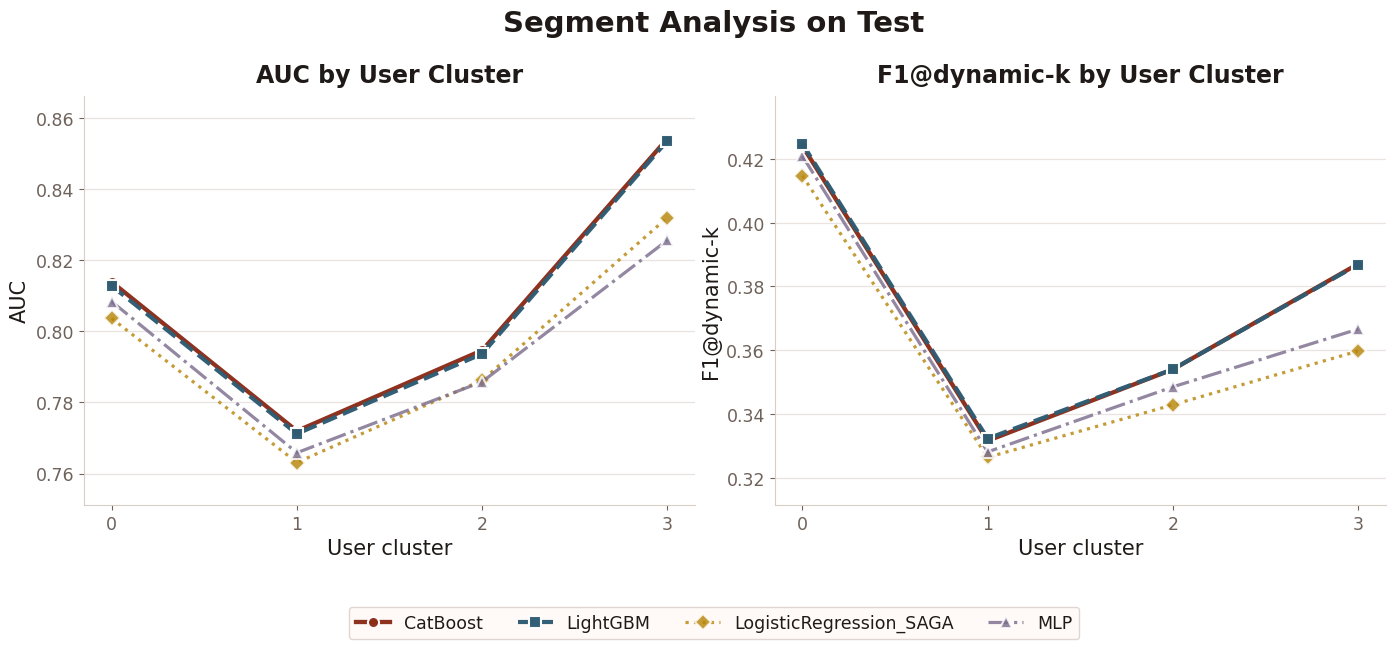

In [20]:
segment_plot_df = segment_summary[segment_summary["split"] == "test"].copy()
model_order = list(segment_plot_df["model"].drop_duplicates())
segments = sorted(segment_plot_df["segment"].unique())

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.2))

for model_name in model_order:
    g = (
        segment_plot_df[segment_plot_df["model"] == model_name]
        .set_index("segment")
        .reindex(segments)
        .reset_index()
    )
    style = model_style(model_name)
    axes[0].plot(g["segment"], g["auc"], markersize=8, markeredgecolor="#FFFFFF", markeredgewidth=1.5, label=model_name, **style)
    axes[1].plot(g["segment"], g["f1@dynamic_k"], markersize=8, markeredgecolor="#FFFFFF", markeredgewidth=1.5, label=model_name, **style)

fig.suptitle("Segment Analysis on Test", fontsize=21, fontweight="bold", y=0.98)
axes[0].set_title("AUC by User Cluster", fontsize=17, pad=10)
axes[0].set_ylabel("AUC")
axes[1].set_title("F1@dynamic-k by User Cluster", fontsize=17, pad=10)
axes[1].set_ylabel("F1@dynamic-k")

auc_min = max(0.0, segment_plot_df["auc"].min() - 0.012)
auc_max = min(1.0, segment_plot_df["auc"].max() + 0.012)
f1_min = max(0.0, segment_plot_df["f1@dynamic_k"].min() - 0.015)
f1_max = min(1.0, segment_plot_df["f1@dynamic_k"].max() + 0.015)
axes[0].set_ylim(auc_min, auc_max)
axes[1].set_ylim(f1_min, f1_max)

for ax in axes:
    ax.set_xticks(segments)
    ax.set_xticklabels([str(s) for s in segments])
    ax.set_xlabel("User cluster")
    finish_axis(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 0.03), frameon=True, facecolor="#FFF9F7", edgecolor=THEME["edge"])
fig.subplots_adjust(top=0.84, bottom=0.18, wspace=0.13)
fig.savefig(OUTPUT_DIR / "segment_analysis_bars_clean.png", dpi=220, bbox_inches="tight")
plt.show()


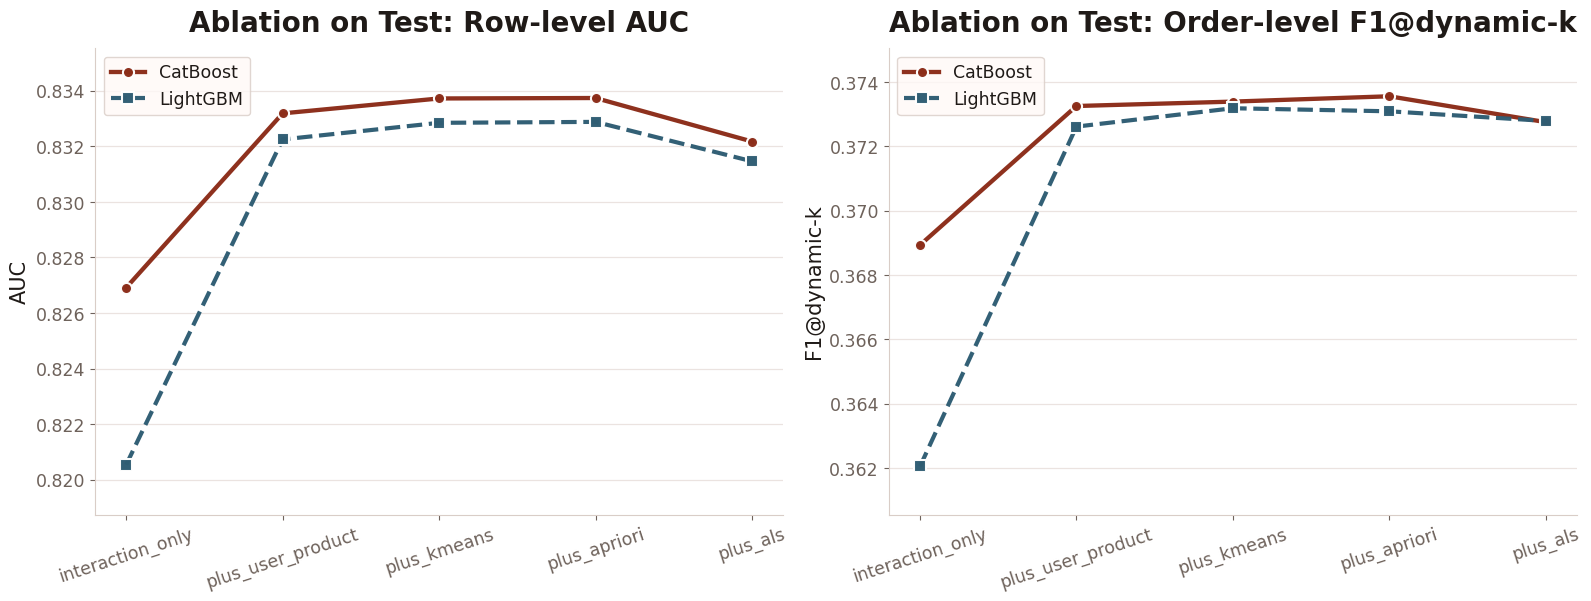

In [21]:
stage_order = ["interaction_only", "plus_user_product", "plus_kmeans", "plus_apriori", "plus_als"]
ablation_plot_df = ablation_summary[ablation_summary["split"] == "test"].copy()
ablation_plot_df["stage"] = pd.Categorical(ablation_plot_df["stage"], categories=stage_order, ordered=True)
ablation_plot_df = ablation_plot_df.sort_values(["model", "stage"])

metric_specs = [
    ("auc", "AUC", "Ablation on Test: Row-level AUC"),
    ("f1@dynamic_k", "F1@dynamic-k", "Ablation on Test: Order-level F1@dynamic-k"),
]

fig, axes = plt.subplots(1, 2, figsize=(15.8, 5.9), constrained_layout=True)

for ax, (metric, ylabel, title) in zip(axes, metric_specs):
    for model_name in ["CatBoost", "LightGBM"]:
        g = ablation_plot_df[ablation_plot_df["model"] == model_name].copy()
        style = model_style(model_name)
        ax.plot(g["stage"].astype(str), g[metric], markersize=8, markeredgecolor="#FFFFFF", markeredgewidth=1.5, label=model_name, **style)
    ax.set_title(title, pad=12)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=18)
    finish_axis(ax)
    values = ablation_plot_df[metric]
    pad = 0.0018 if metric == "auc" else 0.0015
    ax.set_ylim(values.min() - pad, values.max() + pad)
    ax.legend(loc="upper left", frameon=True, facecolor="#FFF9F7", edgecolor=THEME["edge"])

fig.savefig(OUTPUT_DIR / "ablation_curves_clean.png", dpi=220, bbox_inches="tight")
plt.show()


Cleaned figures are saved to:

- `outputs/main_validation_vs_test_auc_clean.png`
- `outputs/segment_analysis_bars_clean.png`
- `outputs/ablation_curves_clean.png`
